In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pytz
import statsmodels.api as sm

In [2]:
start_date = datetime(2020, 1, 1)
end_date = datetime(2024, 12, 3)
stock_symbol = 'PANW'

# Fetch stock data from Yahoo Finance
stock = yf.download(stock_symbol, start=start_date, end=end_date)

# Debugging: Check if stock data is loaded correctly
if stock.empty:
    raise ValueError("Stock data could not be fetched. Please check the stock symbol or internet connection.")

[*********************100%***********************]  1 of 1 completed


In [3]:
start = pd.Timestamp('2023-04-03', tz=pytz.UTC)

win = 60
horizon = 1

# Define a target start date for training (timezone-naive)
#start = pd.Timestamp('2023-04-03')

if start not in stock.index:
    # Find the nearest date if 'start' does not exist in stock index
    start = stock.index.asof(start)

# Find the index of the start date in the stock data
try:
    train_start = stock.index.get_loc(start)
except KeyError:
    raise ValueError(f"The specified start date {start} is not present in the stock data index.")

position = 100

# Initialize dictionaries to store results
y_pred_rf, y_test_rf = {}, {}
signal_rf, gain_loss_rf, balance_rf = {}, {}, {}
balance_rf[train_start] = stock['Close'].iloc[train_start] * position

In [4]:
# Load macro-finance features from CSV file
feature_macro = pd.read_csv('6105_final_selected_price_features.csv', index_col=0)

# Handle length mismatch between feature_macro and stock data
if len(feature_macro) != len(stock):
    print(f"Length mismatch: feature_macro has {len(feature_macro)} rows, stock has {len(stock)} rows.")
    # Trim or align feature_macro to match stock length
    feature_macro = feature_macro.iloc[:len(stock)]

# Shift data to avoid lookahead bias and backfill missing values
feature_macro = feature_macro.shift(1).bfill()

# Align features with stock data index (ensure they match)
feature_macro = feature_macro.set_index(stock.index)

# Prepare features dataset for modeling
features = feature_macro.reset_index(drop=True)

# Debugging: Check if features are aligned correctly
print(features.head())
print(f"Features shape: {features.shape}, Stock shape: {stock.shape}")

Length mismatch: feature_macro has 1239 rows, stock has 1238 rows.
   avg_sell_price_tick  price_high_b  avg_sell_price_wrds  avg_price_m  \
0           234.932484      234.0000           234.943028   234.950166   
1           234.932484      234.0000           234.943028   234.950166   
2           235.935484      235.0000           235.932467   235.968743   
3           238.821808      238.6502           238.850379   238.856095   
4           241.545489      242.2000           241.553137   241.570967   

   avg_buy_price_Retail  price_high_m  avg_buy_price_Inst20k  \
0            234.938682        235.94             234.943330   
1            234.938682        235.94             234.943330   
2            235.958829        237.00             235.978114   
3            238.772184        240.54             238.785646   
4            241.549890        242.53             241.585459   

   avg_buy_price_Inst50k  avg_buy_price_LR  BestBidDepth_Share_tw  
0             234.942602        234

In [5]:
# Initialize required dictionaries
signal_rf, gain_loss_rf, balance_rf, y_pred_rf, y_test_rf = {}, {}, {}, {}, {}

# Set initial balance
#balance_rf[train_start] = stock['Close'].iloc[train_start] * position

# Iterate through the trading days
for today in range(train_start, len(features) - 1):
    yesterday = today - 1
    tomorrow = today + 1

    # Retrieve data for the past win days until yesterday
    X_train = features.iloc[today - win : today]
    y_train = stock['Close'].iloc[today - win : today].values.ravel()

    # Train Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)

    # Make predictions on today's data
    X_test = pd.DataFrame(features.iloc[today].values.reshape(1, -1), columns=features.columns)
    prediction = rf_model.predict(X_test)
    y_pred_rf[today] = float(prediction[0])
    y_test_rf[today] = float(stock['Open'].iloc[today])

    # Day trade gain or loss based on predictions
    if y_pred_rf[today] >= y_test_rf[today]:
        signal_rf[today] = 1  # Buy signal
        gain_loss_rf[today] = -position * stock['Open'].iloc[today] + position * stock['Close'].iloc[today]
    else:
        signal_rf[today] = -1  # Sell signal
        gain_loss_rf[today] = position * stock['Open'].iloc[today] - position * stock['Close'].iloc[today]

    # Update account balance
    balance_rf[tomorrow] = balance_rf.get(today, stock['Close'].iloc[train_start] * position) + gain_loss_rf[today]

    # Debugging output to verify values
    #print(f"Today: {today}, Signal: {signal_rf.get(today)}, Gain/Loss: {gain_loss_rf.get(today)}, Balance: {balance_rf.get(tomorrow)}")



/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_75763/1978390276.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y_test_rf[today] = float(stock['Open'].iloc[today])
/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_75763/1978390276.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y_test_rf[today] = float(stock['Open'].iloc[today])
/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_75763/1978390276.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y_test_rf[today] = float(stock['Open'].iloc[today])
/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_75763/1978390276.py:24: FutureWarning: Calling float on a single element Series is deprecated and wil

In [6]:
# Verify dictionary lengths after loop execution
print(f"Length of signal_rf: {len(signal_rf)}")
print(f"Length of gain_loss_rf: {len(gain_loss_rf)}")
print(f"Length of balance_rf: {len(balance_rf)}")
print(f"Length of y_pred_rf: {len(y_pred_rf)}")
print(f"Length of y_test_rf: {len(y_test_rf)}")

print(f"y pred 0: {y_pred_rf[1236]}")

Length of signal_rf: 419
Length of gain_loss_rf: 419
Length of balance_rf: 419
Length of y_pred_rf: 419
Length of y_test_rf: 419
y pred 0: 388.5455286035798


In [7]:
results_index = stock.index[train_start:train_start + len(signal_rf)]

results_rf1 = pd.DataFrame({
    'signal': pd.Series(signal_rf),
    'gain_loss': pd.Series(gain_loss_rf),
    'balance': pd.Series(balance_rf),
    'y_pred': pd.Series(y_pred_rf),
    'y_test': pd.Series(y_test_rf)
}, index=results_index)


results_rf1['Date'] = results_index
results_rf1.set_index('Date', inplace=True)

# Plot performance: Day Trade vs Buy-and-Hold
results_rf1['buy_hold'] = stock['Close'][train_start:train_start + len(results_index)] * position
results_rf = pd.DataFrame({
    'balance': pd.Series(balance_rf)
})


# Ensure both DataFrames have consistent indices
results_rf.index = results_rf1.index  # Align results_rf index with results_rf1
# Combine results_rf1 and results_rf into a single DataFrame
combined_results = pd.concat([results_rf1['buy_hold'], results_rf['balance']], axis=1)
combined_results.columns = ['buy_hold', 'balance']

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


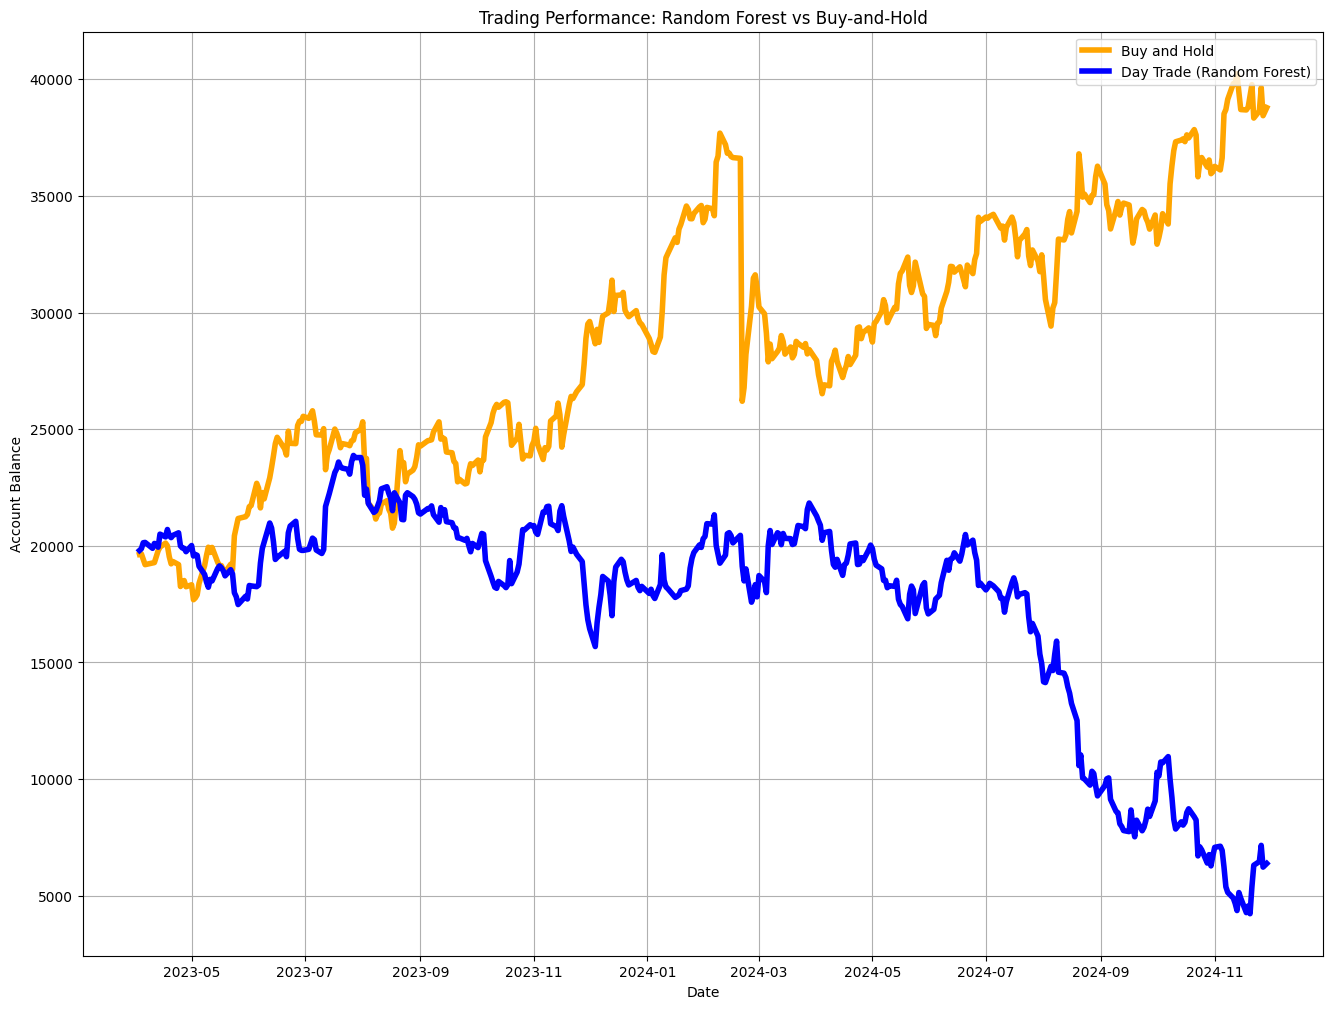

In [8]:
# Plot both Day Trade (Random Forest) and Buy-and-Hold strategies
plt.figure(figsize=(16, 12))

# Plot Buy-and-Hold strategy
plt.plot(combined_results.index, combined_results['buy_hold'], linewidth=4, linestyle='solid', color='orange', label='Buy and Hold')

# Plot Day Trade (Random Forest) strategy
plt.plot(combined_results.index, combined_results['balance'], linewidth=4, linestyle='solid', color='blue', label='Day Trade (Random Forest)')

# Add labels, title, and legend
plt.legend(loc="upper right")
plt.title("Trading Performance: Random Forest vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Account Balance")
plt.grid(True)
plt.show()

In [9]:
signal_rf = pd.DataFrame.from_dict(signal_rf, orient = 'index', columns=['signal'])
gain_loss_rf = pd.DataFrame.from_dict(gain_loss_rf, orient = 'index', columns=['gain_loss'])
balance_rf = pd.DataFrame.from_dict(balance_rf, orient = 'index', columns=['balance'])
y_pred_rf = pd.DataFrame.from_dict(y_pred_rf, orient = 'index', columns=['y_pred'])
y_test_rf = pd.DataFrame.from_dict(y_test_rf, orient = 'index', columns=['y_test'])

In [10]:
# Concatenate DataFrames along columns axis
results = pd.concat([signal_rf, gain_loss_rf, balance_rf, y_pred_rf, y_test_rf], axis=1)
results['Date'] = stock.index[results.index]

# Set the 'date' column as the index
results.set_index('Date', inplace=True)
results['buy_hold'] = stock['Close'].loc[results.index]*position


In [11]:
# Check for missing data in results
print("Checking for missing data in results:")
print(results.isnull().sum())
print("\nSummary statistics for results:")
print(results.describe())

Checking for missing data in results:
signal         0
gain_loss    419
balance      419
y_pred         0
y_test         0
buy_hold       0
dtype: int64

Summary statistics for results:
           signal      y_pred      y_test      buy_hold
count  419.000000  419.000000  419.000000    419.000000
mean    -0.107399  286.376805  286.858377  28719.286359
std      0.995405   55.400104   55.491382   5570.424414
min     -1.000000  176.282369  177.009995  17688.999939
25%     -1.000000  243.752327  243.360001  24320.000458
50%     -1.000000  289.755197  288.519989  28892.001343
75%      1.000000  334.786173  335.580002  33575.999451
max      1.000000  399.195990  402.109985  40235.998535


In [12]:
# Inspect gain_loss column
print("Contents of gain_loss:")
print(results['gain_loss'].head())

# Check if all values are zero
if results['gain_loss'].sum() == 0:
    print("Error: All values in 'gain_loss' are zero.")

Contents of gain_loss:
Date
2023-04-03 00:00:00+00:00    NaN
2023-04-04 00:00:00+00:00    NaN
2023-04-05 00:00:00+00:00    NaN
2023-04-06 00:00:00+00:00    NaN
2023-04-10 00:00:00+00:00    NaN
Name: gain_loss, dtype: object
Error: All values in 'gain_loss' are zero.


In [13]:
# Model Configuration 
print(f"Model Configuration: window = {win} days, starting date = {start}")
print("------------------------------------------------------------------------------------------------")
# Prediction performance:
rmse = np.sqrt(np.mean((results['y_pred']-results['y_test'])**2))
print(f"Root-Mean-Squared-Error (RMSE) {start_date} to {end_date} is {rmse*100:.2f}%.")

# PnL by positions: long vs short
total_PnL = results['gain_loss'].sum()
holding_period_return = (results['balance'][-1]-results['balance'][0])/results['balance'][0]
print(f"The total PnL from {start} to {end_date} is: ${total_PnL:.2f}")
print(f"The total trading return from {start} to {end_date} is: {holding_period_return*100:.2f}%")

Model Configuration: window = 60 days, starting date = 2023-04-03 00:00:00+00:00
------------------------------------------------------------------------------------------------
Root-Mean-Squared-Error (RMSE) 2020-01-01 00:00:00 to 2024-12-03 00:00:00 is 696.39%.
The total PnL from 2023-04-03 00:00:00+00:00 to 2024-12-03 00:00:00 is: $0.00
The total trading return from 2023-04-03 00:00:00+00:00 to 2024-12-03 00:00:00 is: nan%


/var/folders/dn/4sw_n0tj3vj267p4ythp37rr0000gn/T/ipykernel_75763/1844528535.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  holding_period_return = (results['balance'][-1]-results['balance'][0])/results['balance'][0]
